In [2]:
import os

os.environ["OMP_NUM_THREADS"] = "1"

import numpy as np
import emcee
from seaborn import kdeplot
import matplotlib.pyplot as plt
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [3]:
mcmc_samps = np.load("mcmc_results/mcmc_results_5/mcmc_samps_65536_1.npy")
cond_var = np.load("mcmc_results/mcmc_results_5/cond_vars_1.npy")
rej_samps = np.load("rej_results/_5/rej_samps.npy")
cond_ys = np.load("rej_results/_5/conditioning_ys.npy")
cond_idx = np.where(cond_ys == cond_var)[0].item()
rej_samp = rej_samps[cond_idx, :]
nn_samps_ode = np.load("nn_results/ode_5/nn_samps.npy")[1::2]
ode_samp = nn_samps_ode[cond_idx, :]
nn_samps_sde = np.load("nn_sde_results/ode_5/nn_samps.npy")[1::2]
sde_samp = nn_samps_sde[cond_idx, :]

In [4]:
a = 2
b = 0.1
sigma_x = 1

def log_dens(u):
    y = cond_var
    scale = 1 / (2 * sigma_x**2)
    sum_part = (a * (y + b * (u**2 + a**2))) ** 2 + (u**2) / (a**2)
    return -scale * sum_part

In [ ]:
np.random.seed(43)
initial = np.random.randn(16, 1)
nwalkers, ndim = initial.shape
nsteps = 4 ** 6

sampler = emcee.EnsembleSampler(nwalkers, ndim, log_dens)
sampler.run_mcmc(initial, nsteps, progress=True);

100%|██████████| 4096/4096 [00:00<00:00, 5036.23it/s]


In [9]:
np.vstack(sampler.chain)

array([[ 0.57173803],
       [-0.33575793],
       [-0.21573146],
       ...,
       [-6.80738403],
       [-6.80738403],
       [-6.80738403]], shape=(65536, 1))

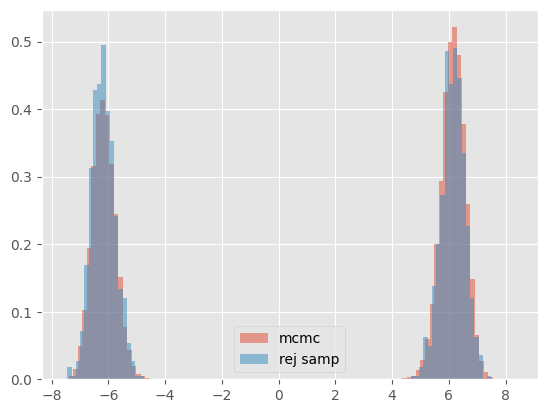

In [10]:
plt.hist(np.vstack(sampler.chain).squeeze(), label="mcmc", bins=100, density=True, alpha=0.5);
plt.hist(rej_samp, label="rej samp", bins=100, density=True, alpha=0.5)
# plt.hist(ode_samp, label="ode", bins=100, density=True, alpha=0.5)
# plt.hist(sde_samp, label="sde", bins=100, density=True, alpha=0.5)
plt.legend()

In [83]:
rej_samp.reshape(-1, 1).shape

(1500, 1)

In [84]:
wd(np.vstack(sampler.chain), rej_samp.reshape(-1, 1))

array([0.68773463])

In [15]:
rej_samp

array([], shape=(0, 1500), dtype=float64)

<Axes: ylabel='Density'>

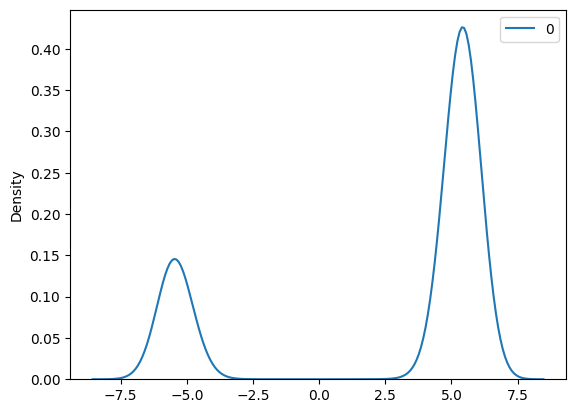

In [28]:
kdeplot(mcmc_samps)

In [29]:
cond_var

array([-2.87572413])

In [1]:
1024 * 16

16384